# Optimising PID Controllers For Wearable Lower-Limb Robots in Python Using a Hybridised Evolutionary Algorithm

In [1]:
import pandas as pd
import sympy as sp
import random as rnd
import numpy as np
import matplotlib.pyplot as plt
import pyswarms as ps

from deap import algorithms
from deap import base
from deap import creator
from deap import tools


def l(sp_func, var):
    """
    Converts `sympy`'s symbolic representation to an evaluable function using `sympy`'s `lambdify()' function.
    :param sp_func: sympy's symbolic representation
    :param var: function's variable
    :return: A callable function
    """
    return sp.lambdify(var, sp_func, modules=['mpmath'])

## Closed-Control Loop Algorithm For WLLR

<img src="Closed-Loop_Control.png"/>

### Joint Angles

#### Desired
$$
    \theta_{d_1}(t) = 0.8\sin\left(\frac{t\pi}{4}\right)
$$

$$
    \theta_{d_2}(t) = 1.5\sin\left(\frac{t\pi}{4}\right)
$$

In [2]:
sym_t = sp.symbols('t')
sym_s = sp.symbols('s')
pi = sp.symbols('pi')

def hip_angle():
    return 0.8 * sp.sin((sym_t * np.pi)/4)

def hip_angle_L():
    return sp.laplace_transform(hip_angle(), sym_t, sym_s)[0]

def knee_angle():
    return 1.5 * sp.sin((sym_t * np.pi)/4)

def knee_angle_L():
    return sp.laplace_transform(knee_angle(), sym_t, sym_s)[0]

td = [
    l(hip_angle(), sym_t),
    l(knee_angle(), sym_t),
]
t1 = l(hip_angle(), sym_t)
t2 = l(knee_angle(), sym_t)

td_l = [
    hip_angle_L(),
    knee_angle_L(),
]
td1_l = l(hip_angle_L(), sym_s)
td2_l = l(knee_angle_L(), sym_s)

In [3]:
# Time space and desired angles
t_space = np.arange(0, 31, 0.2)

# Desired angles
desired = [
    np.array([t1(t) for t in t_space]),
    np.array([t2(t) for t in t_space])
]

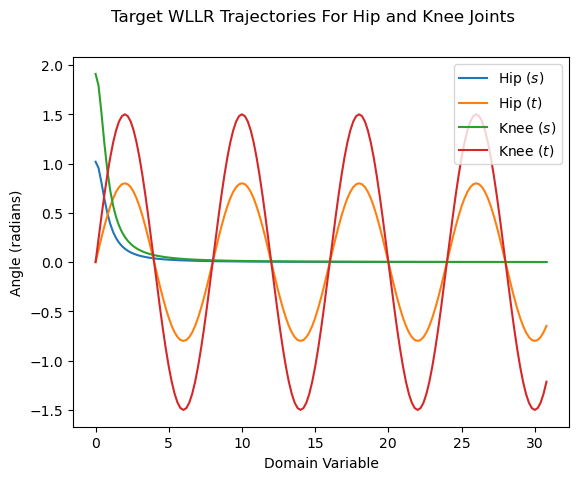

In [4]:
x = np.arange(1, 31, 0.1)

fig, ax = plt.subplots()

ax.plot(t_space, [td1_l(s) for s in t_space], label='Hip ($s$)')
ax.plot(t_space, [t1(t) for t in t_space], label='Hip ($t$)')

ax.plot(t_space, [td2_l(s) for s in t_space], label='Knee ($s$)')
ax.plot(t_space, [t2(t) for t in t_space], label='Knee ($t$)')

ax.set_xlabel('Domain Variable')
ax.set_ylabel('Angle (radians)')

plt.suptitle("Target WLLR Trajectories For Hip and Knee Joints")
plt.legend()

### PID Controller Transfer Function $E_i\to U_i$

$$
    C_i(s)=\frac{U_i(s)}{E_i(s)} = K_p+\frac{K_i}{s}+K_ds
$$

In [5]:
Kp = 0.5
Ki = 0.5
Kd = 0.5

def controller_tf(Kp, Ki, Kd):
    return Kp + Ki/sym_s + Kd*sym_s

C = l(controller_tf(Kp, Ki, Kd), sym_s)
controller_tf(Kp, Ki, Kd)

0.5*s + 0.5 + 0.5/s

Text(0, 0.5, '$C_i(s)$')

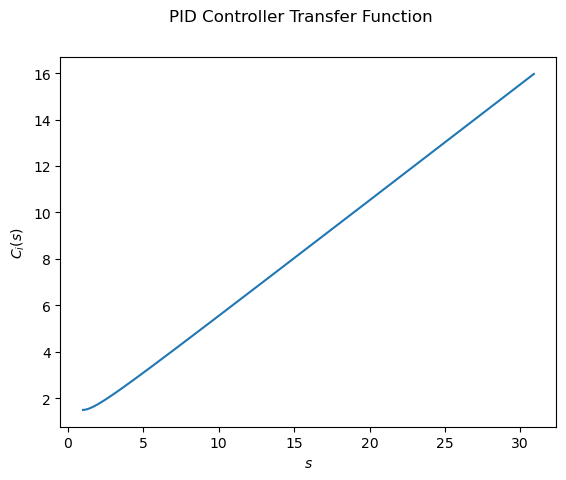

In [6]:
y = np.array([C(s) for s in x])

fig, ax = plt.subplots()
fig.suptitle("PID Controller Transfer Function")

ax.plot(x, y)
ax.set_xlabel('$s$')
ax.set_ylabel('$C_i(s)$')

### Linearised Torque Equations

$$
    T_1 = (m_1d_1^2+I_1+m_2l_1^2)\ddot{\theta_1} + (m_1gd_1+m_2gl_1)\theta_1
$$

$$
    T_2 = (m_2d_2^2+I_2)\ddot{\theta_2}+(m_2gd_2)\theta_2
$$

#### As Transfer Functions $U_i\to \Theta_{a_i}$

$$
    G_1(s)=\frac{Y_1(s)}{U_1(s)}=\frac{1}{(m_1d_1^2+I_1+m_2l_1^2)s^2+m_1gd_1+m_2gl_1}
$$

$$
    G_2(s)=\frac{Y_2(s)}{U_2(s)}=\frac{1}{(m_2d_2^2+I_2)s^2 + m_2gd_2}
$$

In [7]:
GRAVITY = 9.80665
m1, m2 = 2, 1
l1, l2 = 0.35, 0.45
d1, d2 = l1/2, l2/2
I1, I2 = 0.3, 0.18

# T1
def hip_plant_tf():
    return 1 / ((m1*d1**2 + I1 + m2*l1**2)*sym_s**2 + m1 * GRAVITY * d1 + m2 * GRAVITY * l1)

# T2    
def knee_plant_tf():
    return 1 / ((m2*d2**2 + I2)*sym_s**2 + m2 * GRAVITY * d2)

In [8]:
hip_plant_tf()

1/(0.48375*s**2 + 6.864655)

In [9]:
knee_plant_tf()

1/(0.230625*s**2 + 2.20649625)

In [10]:
plant_tf = [
    hip_plant_tf(),
    knee_plant_tf(),
]
G = lambda i: l(plant_tf[i], sym_s)
plant_tf[1]

1/(0.230625*s**2 + 2.20649625)

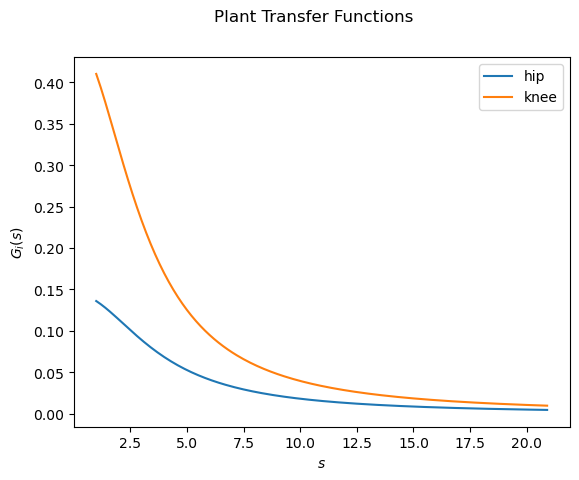

In [11]:
x = np.arange(1, 21, 0.1)

fig, ax = plt.subplots()
fig.suptitle("Plant Transfer Functions")

ax.plot(x, [G(0)(s) for s in x], label='hip')
ax.plot(x, [G(1)(s) for s in x], label='knee')
ax.set_xlabel("$s$")
ax.set_ylabel("$G_i(s)$") 

plt.legend()

### Tracking Error For Each Joint

$$
        e_i(t)=\theta_{d_i}(t)-\theta_{a_i}(t)
$$

#### In Laplace Domain

$$
    E_i(s)=\Theta_{d_i}(s)-\Theta_{a_i}(s)
$$

#### As Transfer Function $\Theta_d\to E$

$$
    \begin{align}
        \frac{E_i(s)}{\Theta_{d_i}(s)}&= 1 - \frac{\Theta_{a_i}(s)}{\Theta_{d_i}(s)}\\
        \\
        &=1-\frac{C_i(s)G_i(s)}{1+C_i(s)G_i(s)}\\
        \\
        &=\frac{1+C_i(s)G_i(s)}{1+C_i(s)G_i(s)}-\frac{C_i(s)G_i(s)}{1+C_i(s)G_i(s)}\\
        \\
        &=\frac{1+C_i(s)G_i(s)-C_i(s)G_i(s)}{1+C_i(s)G_i(s)}\\
        \\
        &=\frac{1}{1+C_i(s)G_i(s)}
    \end{align}
$$

In [12]:
def err_tf(C_tf, G_tf):
    return 1 / (1+C_tf * G_tf)

In [13]:
etf = lambda i: err_tf(controller_tf(Kp,Ki,Kd),plant_tf[i])
E = lambda i: l(etf(i), sym_s)
etf(0)

1/(1 + (0.5*s + 0.5 + 0.5/s)/(0.48375*s**2 + 6.864655))

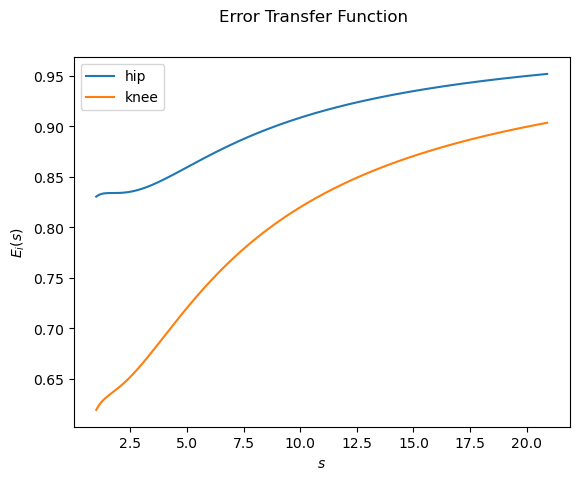

In [14]:
fig, ax = plt.subplots()
fig.suptitle("Error Transfer Function")

ax.plot(x, [E(0)(s) for s in x], label='hip')
ax.plot(x, [E(1)(s) for s in x], label='knee')
ax.set_xlabel("$s$")
ax.set_ylabel("$E_i(s)$")

plt.legend()

### The Model Transfer Function $\Theta_{a_i}\to \Theta_{d_i}$

$$
    \begin{align}
    \frac{\Theta_{a_i}(s)}{\Theta_{d_i}(s)} &= \frac{E_i(s)}{\Theta_{d_i}(s)} \times \frac{U_i(s)}{E_i(s)} \times \frac{\Theta_{a_i}(s)}{U_i(s)}\\
    &=\frac{1}{1+C_i(s)G_i(s)} \times K_p+\frac{K_i}{s}+K_ds \times G_i(s)
    \end{align}
$$

In [15]:
def model_tf(C, G):
    return err_tf(C, G) * C * G

In [16]:
Ta = lambda i: l(model_tf(controller_tf(Kp, Ki, Kd), plant_tf[i]), sym_s)
model_tf(controller_tf(Kp,Ki,Kd), plant_tf[0])

(0.5*s + 0.5 + 0.5/s)/((1 + (0.5*s + 0.5 + 0.5/s)/(0.48375*s**2 + 6.864655))*(0.48375*s**2 + 6.864655))

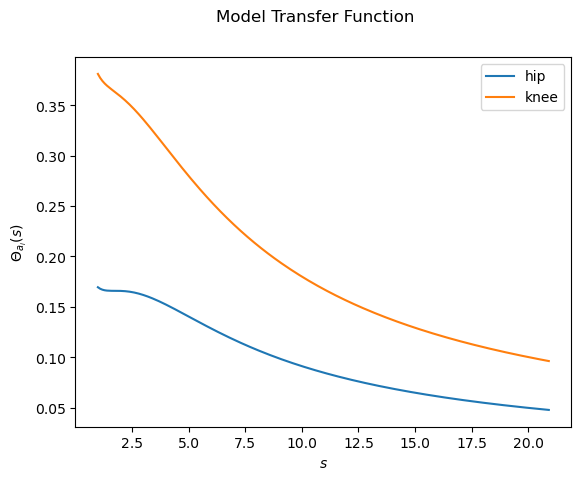

In [17]:
fig, ax = plt.subplots()
fig.suptitle("Model Transfer Function")

ax.plot(x, [Ta(0)(s) for s in x], label='hip')
ax.plot(x, [Ta(1)(s) for s in x], label='knee')
ax.set_xlabel("$s$")
ax.set_ylabel("$Θ_{a_i}(s)$")

plt.legend()

In [18]:
def angle(i, C, G):
    t_a = sp.inverse_laplace_transform(model_tf(C, G) * td_l[i], sym_s, sym_t)
    f = sp.lambdify(sym_t, t_a, modules=['sympy'])
    return f

In [19]:
t_a1f = angle(0, controller_tf(Kp,Ki,Kd), plant_tf[0])
t_a2f = angle(1, controller_tf(Kp,Ki,Kd), plant_tf[1])

ta1 = [t_a1f(t).evalf(chop=True) for t in t_space]
ta2 = [t_a2f(t).evalf(chop=True) for t in t_space]

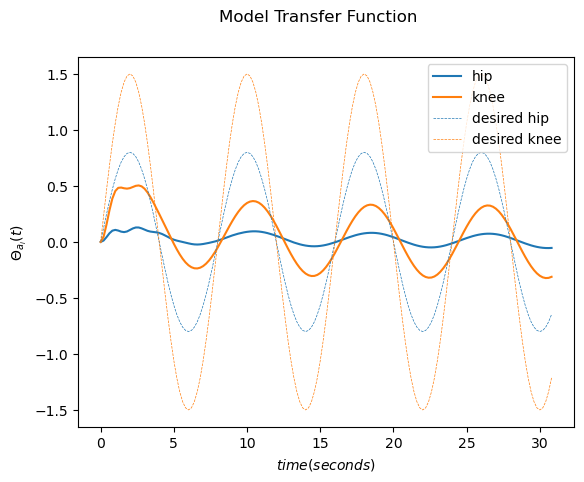

In [21]:
hip_color = '#1f77b4'
knee_color = '#ff7f0e'

fig, ax = plt.subplots()
fig.suptitle("Model Transfer Function")

ax.plot(t_space, ta1, label='hip', color=hip_color)
ax.plot(t_space, ta2, label='knee', color=knee_color)
ax.plot(t_space, [t1(t) for t in t_space], label='desired hip', color=hip_color, ls='--', lw=0.5)
ax.plot(t_space, [t2(t) for t in t_space], label='desired knee', color=knee_color, ls='--', lw=0.5)

ax.set_xlabel("$time (seconds)$")
ax.set_ylabel("$Θ_{a_i}(t)$")

plt.legend()

### Non-Optimised Simulation Loop

In [26]:
# Time space
t_space = np.arange(0, 11, 1)

# Actual angles
angles = [[],[]]

# Error tracking
err = [[],[]]

# Simulation Loop
for t in t_space:
    for i in range(2):
        print(f"\rSimulating second {round(t,2)}/{t_space[-1]}; {("hip" if i == 0 else "knee")}           ", end="")
        theta_d = td[i](t)
        Kp,Ki,Kd = tuple(np.random.random(size=3))
        C = controller_tf(Kp,Ki,Kd)
        G = plant_tf[i]
        theta_a = complex(angle(i, C, G)(t).evalf(chop=True))
        
        angles[i].append(theta_a)
        err[i].append(theta_d - float(theta_a.real))
print()

Simulating second 10/10; knee           


E:\Anaconda\Anaconda\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
E:\Anaconda\Anaconda\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


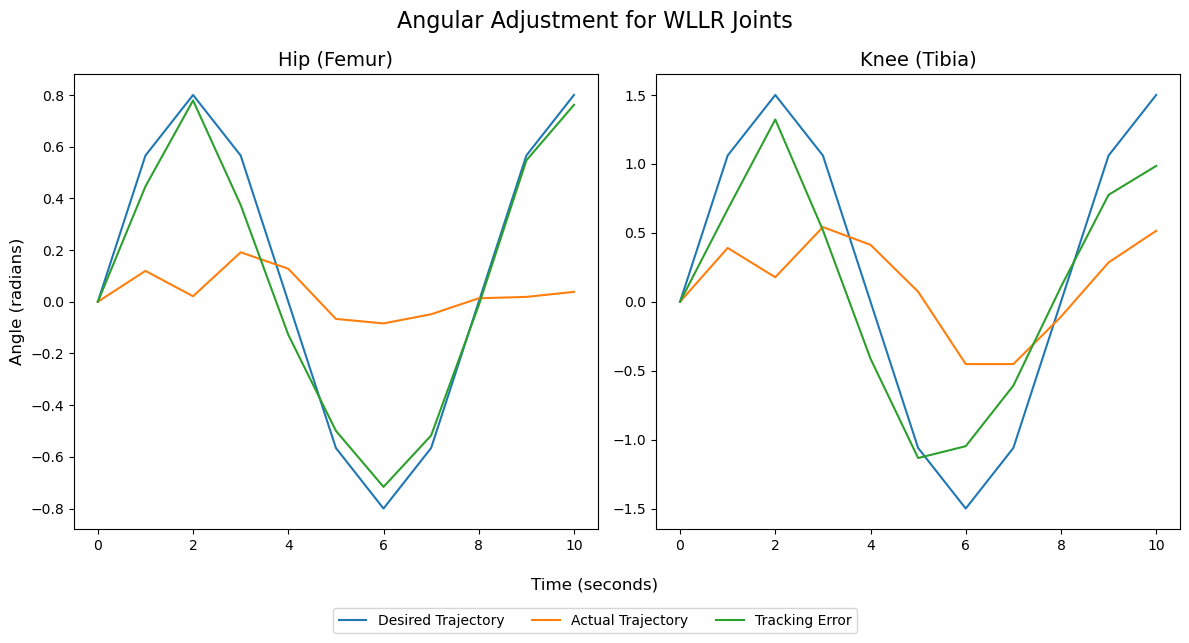

In [30]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))
fig.suptitle("Angular Adjustment for WLLR Joints", size=16)
axs = axs.flatten()

# Plot
label_d = ["Desired Trajectory", '']
label_a = ["Actual Trajectory", '']
label_e = ["Tracking Error", '']

title = ["Hip (Femur)", "Knee (Tibia)"]

for i in range(2):
    axs[i].plot(t_space, [td[i](t) for t in t_space], label=label_d[i])
    axs[i].plot(t_space, angles[i], label=label_a[i])
    axs[i].plot(t_space, [float(e.real) for e in err[i]], label=label_e[i])
    axs[i].set_title(title[i], size=14)
     

axs[0].set_ylabel("Angle (radians)", size=12)
fig.supxlabel("Time (seconds)")

fig.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.07),
    ncols=3
)
fig.tight_layout()

In [29]:
raise ValueError()

ValueError: 

## Exploration with GA

### Setup

| Property                 | Value             |
|:-------------------------|:------------------|
| Python Library           | DEAP              |
| Chromosome $x_{ij}$      | $[K_p,K_i,K_d]$   |
| Pop Size $n$             | 30                |
| Generations $k_H$, $k_K$ | H:60, K:60        |
| Fitness $f_{obj}$        | $\min(ITAE)$      |
| Selection `SEL()`        | `tournament()`    |
| Crossover `CX()`         | `arithmetic(0.8)` |
| Mutation `MUT()`         | `gaussian(0.2)`   |
| Elites fraction $F$      | 0.05              |


### Representation

In [28]:
A, B = -1, 1

creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)
toolbox = base.Toolbox()

toolbox.register("param", rnd.uniform, A, B)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.param, n=3)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.ga_sigma = 1.0

In [29]:
pop = toolbox.population(n=30)
pd.DataFrame(pop, columns=["Kp", "Ki", "Kd"])

,Kp,Ki,Kd
0,0.980357,-0.511524,0.965279
1,-0.680178,0.709396,0.538671
2,-0.709386,-0.424408,-0.700423
3,0.063174,-0.381442,-0.983858
4,0.223004,0.207356,-0.445178
5,-0.245767,-0.445743,-0.064022
6,-0.999358,0.358705,0.424372
7,0.603666,-0.325983,0.161671
8,-0.624014,0.467542,0.701325
9,-0.517164,0.174243,0.139643


### Objetive Function (ITAE)

$$
    ITAE = \int_0^\infty\ t|e_{obj_i}(t)| dt
$$
such that
$$
    E_{obj_i}(s) = 1 - \frac{C_i(t)G_i(t)}{1+C_i(t)G_i(t)}
$$

In [32]:
def E_obj(C, G):
    return 1 - (err_tf(C, G) * C * G)

E = E_obj(controller_tf(Kp,Ki,Kd), plant_tf[0])

In [33]:
E_inv = sp.inverse_laplace_transform(E, sym_s, sym_t)
f = sp.lambdify(sym_t, E_inv, modules=['sympy'])
f(5).evalf(chop=True)

-0.232109873170698

In [34]:
def e_obj(i, t, pid):
    C = controller_tf(pid[0], pid[1], pid[2])
    G = plant_tf[i]
    
    E = E_obj(C, G)
    E_inv = sp.inverse_laplace_transform(E, sym_s, sym_t)
    f = sp.lambdify(sym_t, E_inv, modules=['sympy'])
    
    return f(t).evalf(chop=True)

def itae(i, pid, t_space):
    e = [t*abs(e_obj(i, t, pid)) for t in t_space]
    return np.trapz(e, t_space),

def f_obj(i, individual, t_space):
    return itae(i, individual, t_space)

In [35]:
ind = pop[rnd.randint(0, len(pop)-1)]
ind = 0.0200101, 0.0002, 0.000003
print(f"ind: {ind}")
dt = itae(0, ind, t_space)
dt

ind: (0.0200101, 0.0002, 3e-06)


(0.338323599693654,)

### Genetic Operators

#### Arithmetic Crossover

***Source:*** PIR Sensors Deployment with the Accessible Priority in Smart Home Using Genetic Algorithm

$$
    \begin{align}
        c_1 &= \lfloor\alpha p_1 + (1-\alpha) p_2 \rfloor\\
        \\
        c_2 &= \lfloor(1-\alpha) p_1 + \alpha p_2 \rfloor
    \end{align}
$$
where $p_i$ is the $i$-th parent, $c_i$ is the $i$-th child, and $\alpha\in(0,1)$

In [295]:
# Src: PIR_Sensors_Deployment
def cx_arithmetic(ind1, ind2):
    alpha = rnd.uniform(0, 1)
    start = rnd.randint(0, len(ind1) - 1)
    end = rnd.randint(start + 1, len(ind1))
    # print(start, end)
    partition = list(range(start, end))
    
    for i in partition:
        ind2[i] = np.floor(alpha * ind1[i] + (1 - alpha) * ind2[i])
        ind1[i] = np.floor(alpha * ind2[i] + (1 - alpha) * ind1[i])
    
    return ind1, ind2

In [296]:
p1 = toolbox.individual()
p2 = toolbox.individual()

print(p1)
print(p2)

c1, c2 = cx_arithmetic(p1, p2)

print(c1)
print(c2)

[-0.20137445801897003, -0.7145689705883334, 0.2485605682402272]
[-0.11368880771554446, -0.98614734185801, -0.520194358347772]
[-0.20137445801897003, -1.0, 0.2485605682402272]
[-0.11368880771554446, -1.0, -0.520194358347772]


#### Gaussian Mutation With Shrink

In [297]:
def shrink_sigma(sigma, shrink, gen, ngens):
    return sigma * (1 - shrink * (gen/ngens))

In [298]:
def gauss(mu, sigma):
    return rnd.gauss(mu, sigma)

In [299]:
#Src: http://neo.lcc.uma.es/cEA-web/GMut.htm
def mut_gauss(individual, ngens, mu, shrink, mtpb):
    sigma = toolbox.ga_sigma
    for i in range(len(individual)):
        if rnd.random() < mtpb:
            individual[i] += gauss(mu, sigma)
            
    toolbox.ga_sigma = shrink_sigma(sigma, shrink, toolbox.gen, ngens)
    toolbox.gen += 1
    return individual,

In [300]:
toolbox.ga_sigma = 1.
toolbox.gen = 1

In [301]:
ind = toolbox.individual()
print(ind)
print(toolbox.gen)
print(toolbox.ga_sigma)
ind, = mut_gauss(ind, 100, 0, 1.0, 0.8)
print(ind)
sigs = [5]  

[0.04448154442581753, 0.5404554627267575, -0.013190740906954268]
1
1.0
[-0.3242516350915646, 1.7830909392102436, -0.8618028870781594]


### GA Main

In [312]:
def GA_main(i, t_space, options):
    toolbox.gen = 1
    toolbox.ga_sigma = options['s0']
    
    toolbox.register("evaluate", lambda x: itae(i, x, t_space))
    toolbox.register("mate", cx_arithmetic)
    
    #Src: https://deap.readthedocs.io/en/master/api/tools.html#deap.tools.mutGaussian, https://uk.mathworks.com/help/gads/genetic-algorithm-options.html#f6633
    toolbox.register("mutate", mut_gauss, ngens=options['n'], mu=options['mtmu'], shrink=options['s-1'], mtpb=options['mtpb'])
    
    #Src: https://uk.mathworks.com/help/gads/genetic-algorithm-options.html 
    toolbox.register("select", tools.selTournament, tournsize=4)
    
    pop = toolbox.population(n=30)
    hof = tools.HallOfFame(1)
    
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    pop, log = algorithms.eaSimple(
        pop,
        toolbox,
        cxpb=options['cxpb'],
        mutpb=1.0,
        ngen=options['n'],
        stats=stats,
        halloffame=hof,
        verbose=True
    )
    
    return pop, log, hof

In [313]:
joint = 0
ga_options = {
    'n': 60,
    's0': 1.0,
    's-1': 1.0,
    'mtmu': 0,
    'mtpb': 0.2,
    'cxpb': 0.8
}

pop, log, hof = GA_main(i, t_space, ga_options)
best = hof[0]
print(best)                                            

avg = log.select('avg')
std = log.select('std')
lo = log.select('min')
hi = log.select('max')

KeyboardInterrupt: 

## Exploitation With PSO

#### Setup

| Property                        | Value           |
|:--------------------------------|:----------------|
| Python Library                  | PySwarms        |
| Particle $\bar{p}_{ij}$         | $[K_p,K_i,K_d]$ |
| Swarm size $n$                  | 30              |
| Iterations $k_H$, $k_K$         | H:40, K:40      |
| Fitness $f_{obj}$               | $\min(ITAE)$    |
| Cognitive Coefficient $C_1$     | 1.5             |
| Social Coefficient $C_2$        | 2               |
| Initial Inertia Weight $\omega$ | 0.05            |
| Tolerance parameter $y$         | unknown         |

### Vectoriesd PSO Cost Function

In [42]:
def of_as_vector(swarm, t, i):
    n_particles = swarm.shape[0]
    costs = np.zeros(n_particles)
    
    for p in range(n_particles):
        Kp, Ki, Kd = swarm[p]
        ind = np.array([Kp, Ki, Kd])
        costs[p] = itae(t, i, ind)[0]
    return costs

swarm = np.array(toolbox.population(30))

In [43]:
of_as_vector(swarm, 5, 0)

array([ 501.90983176, 1439.44542696,  654.51021328,  518.36650213,
        401.85498376,  373.82101773,  116.34388275,  699.92750249,
        165.5604827 ,  272.63699863,  399.33039966,  582.95733037,
        441.18334229,  222.44327969, 3662.74861416,  458.75738316,
        127.91735209,  824.16199029,  710.91850814,  373.71459995,
        989.94326321,  135.56220952,  177.97034635,  257.41194761,
        133.5136861 , 1211.57218328,  637.32835783,  125.05418136,
        915.08234193,  125.02759218])

In [45]:
def PSO_main(options, t, i):
    init_pos = np.array([np.array(options['X'])*rnd.uniform(-1, 1) for _ in range(30)])
    pso = ps.single.GlobalBestPSO(
        n_particles = pso_options['n'],
        dimensions=3,
        options={
            'c1': options['c1'],
            'c2': options['c2'],
            'w': options['w']},
        bounds=options['B'],
        init_pos=init_pos
    )
    
    cost, pos = pso.optimize(lambda s: of_as_vector(s, t, i), iters=40)
    return pos

In [46]:
pso_options = {
    'n':    30,
    'c1':   1.5,
    'c2':   2,
    'w':    0.05,
    'X':    np.array([0.9070548024227184, 6.911271001060211e-05, 0.0]),
    'B':    np.array([[-1,-1,-1],[1,1,1]])*10
}

PSO_main(pso_options, 4, 0)

2025-11-30 14:56:24,751 - pyswarms.single.global_best - INFO - Optimize for 40 iters with {'c1': 1.5, 'c2': 2, 'w': 0.05}
pyswarms.single.global_best: 100%|██████████|40/40, best_cost=32.5
2025-11-30 14:56:49,307 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 32.474195580351775, best pos: [9.99916491e+00 5.53706673e-02 8.43660059e-03]


array([9.99916491e+00, 5.53706673e-02, 8.43660059e-03])

##  Hybrid GA-PSO

In [47]:
def hgapso(t, i):    
    _, _, hof = GA_main({
        'n': 60,
        's0': 1.0,
        's-1': 1.0,
        'mtmu': 0,
        'mtpb': 0.2,
        'cxpb': 0.8
    }, t, i)
    best = hof[0]
    
    pos = PSO_main({
        'n':    30,
        'c1':   1.5,
        'c2':   2,
        'w':    0.05,
        'X':    np.array(best),
        'B':    np.array([[-1,-1,-1],[1,1,1]])*10
    }, i, t)
    return pos

In [48]:
hgapso(1, 0)

2025-11-30 14:56:57,801 - pyswarms.single.global_best - INFO - Optimize for 40 iters with {'c1': 1.5, 'c2': 2, 'w': 0.05}
pyswarms.single.global_best: 100%|██████████|40/40, best_cost=55.2
2025-11-30 14:57:25,600 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 55.2274558831911, best pos: [9.89485368 0.07534366 0.01716165]


array([9.89485368, 0.07534366, 0.01716165])